kostya: пробую

In [2]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data=csvFuturesSimData()
data

Configuring sim logging


csvFuturesSimData object with 252 instruments

In [3]:
data.get_instrument_list()

['AEX',
 'AEX_mini',
 'ALUMINIUM',
 'ALUMINIUM_LME',
 'AUD',
 'AUDJPY',
 'AUD_micro',
 'BB3M',
 'BBCOMM',
 'BITCOIN',
 'BOBL',
 'BONO',
 'BOVESPA',
 'BRE',
 'BRENT-LAST',
 'BRENT_W',
 'BTP',
 'BTP3',
 'BUND',
 'BUTTER',
 'BUXL',
 'CAC',
 'CAD',
 'CAD10',
 'CAD2',
 'CAD5',
 'CAD_micro',
 'CANOLA',
 'CH10',
 'CHEESE',
 'CHF',
 'CHFJPY',
 'CHF_micro',
 'CHINAA-CON',
 'CLP',
 'CNH-onshore',
 'CNH',
 'COAL-GEORDIE',
 'COAL',
 'COCOA',
 'COCOA_LDN',
 'COFFEE',
 'COPPER-micro',
 'COPPER-mini',
 'COPPER',
 'COPPER_LME',
 'CORN',
 'CORN_mini',
 'COTTON',
 'COTTON2',
 'CRUDE_ICE',
 'CRUDE_W',
 'CRUDE_W_micro',
 'CRUDE_W_mini',
 'CZK',
 'DAX',
 'DJSTX-SMALL',
 'DOW',
 'DOW_mini',
 'DX',
 'EPRA-EUROPE',
 'ETHANOL',
 'ETHER-micro',
 'ETHEREUM',
 'EU-AUTO',
 'EU-BANKS',
 'EU-BASIC',
 'EU-CHEM',
 'EU-CONSTRUCTION',
 'EU-DIV30',
 'EU-DJ-OIL',
 'EU-DJ-TECH',
 'EU-DJ-TELECOM',
 'EU-DJ-UTIL',
 'EU-FOOD',
 'EU-HEALTH',
 'EU-HOUSE',
 'EU-INSURE',
 'EU-MEDIA',
 'EU-MID',
 'EU-OIL',
 'EU-REALESTATE',
 'EU-RE

In [4]:
data.get_instrument_object_with_meta_data("MUMMY")

futuresInstrumentWithMetaData(instrument=MUMMY, meta_data={'Description': 'TSE Mothers Index', 'Pointsize': 1000.0, 'Currency': 'JPY', 'AssetClass': 'Equity', 'PerBlock': 50.0, 'Percentage': 0.0, 'PerTrade': 0, 'Region': 'ASIA'})

In [ ]:
data.get_raw_price("SOFR").tail(5)

index
2024-03-28 17:00:00    96.415
2024-03-28 18:00:00    96.415
2024-03-28 19:00:00    96.410
2024-03-28 20:00:00    96.405
2024-03-28 23:00:00    96.405
Name: price, dtype: float64

In [7]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    ## price: This is the stitched price series
    ## We can't use the price of the contract we're trading, or the volatility will be jumpy
    ## And we'll miss out on the rolldown. See https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly

    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

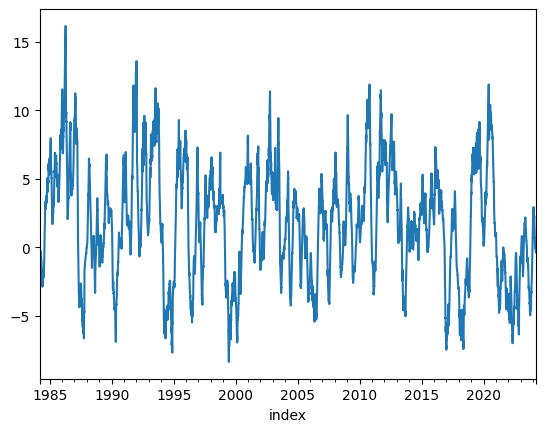

In [8]:
instrument_code='SOFR'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

In [9]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-5.81'),
  ('max', '5.141'),
  ('median', '0'),
  ('mean', '0.01263'),
  ('std', '0.4897'),
  ('skew', '-0.2253'),
  ('ann_mean', '3.232'),
  ('ann_std', '7.836'),
  ('sharpe', '0.4125'),
  ('sortino', '0.4848'),
  ('avg_drawdown', '-11.12'),
  ('time_in_drawdown', '0.9742'),
  ('calmar', '0.08974'),
  ('avg_return_to_drawdown', '0.2907'),
  ('avg_loss', '-0.3111'),
  ('avg_gain', '0.3172'),
  ('gaintolossratio', '1.019'),
  ('profitfactor', '1.092'),
  ('hitrate', '0.5173'),
  ('t_stat', '2.634'),
  ('p_value', '0.008446')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

3.232285596931933

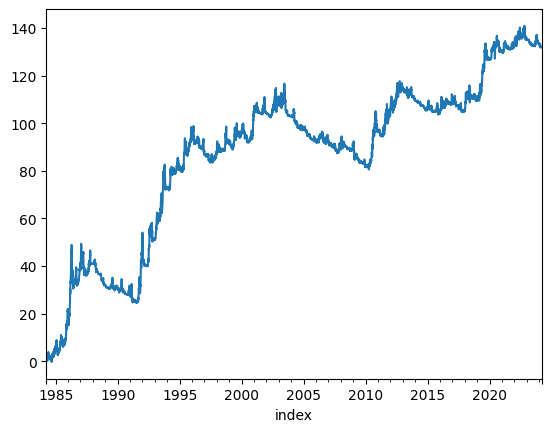

In [11]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
account.percent  ## gives a % curve
#syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
account.weekly  ## weekly returns (also daily [default], monthly, annual)
account.gross.ann_mean()  ## annual mean for gross returns, also costs (there are none in this simple example)